# Adaptive Fusion Portfolio Optimisation System (POC)
**By: Alasteir Ho at University of Greenwich**  


---

### Pipeline overview
| # | Section | Description |
|---|---------|-------------|
| 1 | Configuration | All tunable parameters |
| 2 | Price & Sentiment Data | yfinance daily OHLCV + sentiment CSVs |
| 3 | Feature Engineering | RSI, MACD, Bollinger, momentum, Z-scores, context |
| 4 | Adaptive Fusion Network | PyTorch attention-based fusion (train + inference) |
| 5 | Portfolio Optimiser | MVO / Sharpe-ratio maximisation (SLSQP) |
| 6 | Backtest Engine | Event-driven backtest with real execution prices |
| 7 | Benchmarks | SPY B&H, Equal-Weight, Price-Only, Static-Fusion |
| 8 | Run All Strategies | Execute full pipeline |
| 9 | Results & Visualisations | 5 figures + metrics summary table |

## 1 · Configuration
All tunable parameters in one place — the only section you need to edit.

In [1]:
from pathlib import Path
import torch, os

RETRAIN = True    # True: retrain; False: load saved model if available

INITIAL_NAV = 10_000.0

NOTEBOOK_DIR         = Path().resolve()
NEWS_SENTIMENT_DIR   = NOTEBOOK_DIR / "Processed_Data" / "news_sentiment_daily"
SOCIAL_SENTIMENT_DIR = NOTEBOOK_DIR / "Processed_Data" / "tweets_sentiment_daily"
OUTPUT_DIR           = NOTEBOOK_DIR / "outputs"
MODEL_PATH           = NOTEBOOK_DIR / "fusion_network.pt"
OUTPUT_DIR.mkdir(exist_ok=True)

DATE_COL            = "date"
SENTIMENT_SCORE_COL = "sentiment_score"
NEWS_CSV_SUFFIX     = "_news_sentiment_daily.csv"
SOCIAL_CSV_SUFFIX   = "_tweets_sentiment_daily.csv"

TICKERS = [
    "AAPL","AMZN","AVGO","BRK-B","GOOGL",
    "HD",  "JNJ", "JPM", "LLY",  "MA",
    "META","MSFT","NVDA","ORCL", "PG",
    "TSLA","UNH", "V",   "WMT",  "XOM",
]

SECTOR_MAP = {
    "AAPL":"Technology",  "AVGO":"Technology",  "MSFT":"Technology",
    "NVDA":"Technology",  "ORCL":"Technology",
    "AMZN":"ConsumerDiscretionary","HD":"ConsumerDiscretionary","TSLA":"ConsumerDiscretionary",
    "GOOGL":"Communication","META":"Communication",
    "BRK-B":"Financials","JPM":"Financials","MA":"Financials","V":"Financials",
    "JNJ":"Healthcare",  "LLY":"Healthcare",  "UNH":"Healthcare",
    "PG":"ConsumerStaples","WMT":"ConsumerStaples",
    "XOM":"Energy",
}
SECTORS = sorted(set(SECTOR_MAP.values()))

DATA_START     = "2023-10-10"
BACKTEST_START = "2024-08-31"
BACKTEST_END   = "2025-08-31"
TRAIN_END      = BACKTEST_START

TOP_N_STOCKS   = 10
MIN_WEIGHT     = 0.05
MAX_WEIGHT     = 0.20
REBALANCE_DAYS = 10

# Execution price = yfinance daily Open + SLIPPAGE_BPS
SLIPPAGE_BPS      = 5           # one-way slippage estimate (bps)
SEC_FEE_RATE      = 0.0000278   # SEC fee per $ of sell proceeds
FINRA_TAF_PER_SH  = 0.000166    # FINRA TAF per share sold (capped $8.30)

RSI_PERIOD        = 14
MACD_FAST         = 12
MACD_SLOW         = 26
MACD_SIGNAL       = 9
BB_PERIOD         = 20
BB_STD            = 2
MOMENTUM_PERIOD   = 20
VOLATILITY_WINDOW = 20

N_FACTORS     = 6
CONTEXT_DIM   = 64
HIDDEN_DIM    = 32
LEARNING_RATE = 1e-3
TRAIN_EPOCHS  = 150
BATCH_SIZE    = 64
DROPOUT_RATE  = 0.2
WEIGHT_DECAY  = 1e-4
RANDOM_SEED   = 42
STATIC_WEIGHTS = [0.20, 0.15, 0.15, 0.15, 0.20, 0.15]

DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BENCHMARK_TICKER = "SPY"
RISK_FREE_RATE   = 0.0

FACTOR_COLS = [
    "z_news_sentiment","z_social_sentiment",
    "z_rsi","z_macd","z_momentum","z_bb_width",
]
CONTEXT_COLS = (
    ["volatility_regime","news_intensity","social_intensity"]
    + [f"sector_{s}" for s in SECTORS]
)

print(f"Device         : {DEVICE}")
print(f"Tickers        : {len(TICKERS)}")
print(f"Backtest       : {BACKTEST_START} → {BACKTEST_END}")
print(f"Execution price: yfinance daily Open + {SLIPPAGE_BPS} bps slippage")

Device         : cuda
Tickers        : 20
Backtest       : 2024-08-31 → 2025-08-31
Execution price: yfinance daily Open + 5 bps slippage


---
## 2 · Price & Sentiment Data (yfinance)
Daily OHLCV fetched via yfinance for all 20 tickers. Sentiment CSVs are loaded from
`Processed_Data/` and aligned to the price index, then shifted forward by one trading day
so no same-day sentiment leaks into the feature set.

In [2]:
import logging, warnings
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def fetch_price_data(tickers, start, end):
    price_data = {}
    print(f"Fetching daily OHLCV for {len(tickers)} tickers …", end=" ")
    for t in tickers:
        try:
            raw = yf.download(t, start=start, end=end, auto_adjust=True, progress=False)
            if raw.empty: continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.index = pd.to_datetime(raw.index).normalize()
            price_data[t] = raw[["Open","High","Low","Close","Volume"]].copy()
        except Exception as e:
            print(f"\n  Warning: {t} - {e}")
    print(f"done ({len(price_data)}/{len(tickers)})")
    return price_data

def _load_csv(path, label):
    if not path.exists(): return None
    try:
        df = pd.read_csv(path, parse_dates=[DATE_COL])
        df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.normalize()
        df = df.drop_duplicates(DATE_COL).set_index(DATE_COL)
        s  = df[SENTIMENT_SCORE_COL].astype(float); s.name = label
        return s
    except: return None

def load_sentiment_data(tickers, start, end, news_dir, social_dir):
    print(f"News dir    : {news_dir}")
    print(f"Social dir  : {social_dir}")
    date_range = pd.bdate_range(start=start, end=end, freq="C")
    sentiment  = {}
    for t in tickers:
        ns = _load_csv(news_dir   / f"{t}{NEWS_CSV_SUFFIX}",   "news_sentiment")
        ss = _load_csv(social_dir / f"{t}{SOCIAL_CSV_SUFFIX}", "social_sentiment")
        c  = pd.DataFrame(index=date_range)
        c["news_sentiment"]   = ns.reindex(date_range) if ns is not None else 0.0
        c["social_sentiment"] = ss.reindex(date_range) if ss is not None else 0.0
        c["news_available"]   = (ns.reindex(date_range).notna().astype(float)
                                  if ns is not None else 0.0)
        sentiment[t] = c.ffill(limit=3).fillna(0.0).clip(-1.0, 1.0)
    print(f"Loaded sentiment for {len(sentiment)}/{len(tickers)} tickers")
    return sentiment

def build_master_dataset(price_data, sentiment_data):
    master = {}
    for t in price_data:
        p = price_data[t].copy()
        if t in sentiment_data:
            merged = p.join(sentiment_data[t].shift(1), how="left")  # +1 day shift
        else:
            merged = p.copy()
            merged[["news_sentiment","social_sentiment","news_available"]] = 0.0
        master[t] = merged.ffill(limit=3).fillna(0.0)
    return master

def fetch_spy_returns(start, end):
    spy = yf.download(BENCHMARK_TICKER, start=start, end=end,
                      auto_adjust=True, progress=False)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)
    spy.index = pd.to_datetime(spy.index).normalize()
    return spy["Close"].pct_change().dropna().rename("SPY")

price_data     = fetch_price_data(TICKERS, DATA_START, BACKTEST_END)
spy_returns    = fetch_spy_returns(BACKTEST_START, BACKTEST_END)
sentiment_data = load_sentiment_data(TICKERS, DATA_START, BACKTEST_END,
                                     NEWS_SENTIMENT_DIR, SOCIAL_SENTIMENT_DIR)
master_data    = build_master_dataset(price_data, sentiment_data)
print(f"\nMaster dataset ready: {len(master_data)} tickers")

Fetching daily OHLCV for 20 tickers … done (20/20)
News dir    : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\Processed_Data\news_sentiment_daily
Social dir  : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\Processed_Data\tweets_sentiment_daily
Loaded sentiment for 20/20 tickers

Master dataset ready: 20 tickers


---
## 3 · Feature Engineering

Six Z-scored factors for the fusion network + context features for the attention encoder.  
All Z-scores use **expanding windows** no look-ahead bias at any point.

| Factor | Source | Literature |
|--------|--------|-----------|
| News sentiment (Z) | FinBERT / GDELT | Araci (2019), Shen et al. (2022) |
| Social sentiment (Z) | FinRoBERTa / Twitter | Bollen et al. (2011) |
| RSI (Z) | Close price | Wilder (1978) |
| MACD histogram (Z) | Close price | Appel (2005) |
| Momentum 20d (Z) | Close price | Jegadeesh & Titman (1993) |
| Bollinger Band width (Z) | Close price | Ramlall (2016) |

In [3]:
def compute_rsi(close, period=RSI_PERIOD):
    delta    = close.diff()
    avg_gain = delta.clip(lower=0).ewm(com=period-1, min_periods=period).mean()
    avg_loss = (-delta.clip(upper=0)).ewm(com=period-1, min_periods=period).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return ((100 - 100/(1+rs)) - 50) / 50

def compute_macd(close):
    hist = (close.ewm(span=MACD_FAST, adjust=False).mean()
           - close.ewm(span=MACD_SLOW, adjust=False).mean())
    hist -= hist.ewm(span=MACD_SIGNAL, adjust=False).mean()
    return (hist / close).fillna(0)

def compute_bb_width(close):
    sma = close.rolling(BB_PERIOD).mean()
    return ((2*BB_STD*close.rolling(BB_PERIOD).std()) / sma.replace(0, np.nan)).fillna(0)

def compute_momentum(close):
    return close.pct_change(MOMENTUM_PERIOD).fillna(0)

def compute_vol_regime(close):
    rv  = close.pct_change().rolling(VOLATILITY_WINDOW).std()
    q33 = rv.expanding().quantile(0.33)
    q66 = rv.expanding().quantile(0.66)
    r   = pd.Series(1, index=close.index)
    r[rv <= q33] = 0;  r[rv > q66] = 2
    return r.astype(float)

def expanding_zscore(s, min_periods=30):
    mu  = s.expanding(min_periods=min_periods).mean()
    std = s.expanding(min_periods=min_periods).std().replace(0, np.nan)
    return ((s - mu) / std).clip(-3, 3).fillna(0)

def sector_onehot(ticker):
    vec = np.zeros(len(SECTORS), dtype=np.float32)
    sec = SECTOR_MAP.get(ticker, SECTORS[0])
    if sec in SECTORS: vec[SECTORS.index(sec)] = 1.0
    return vec

def build_features(master):
    all_features = {}
    for ticker, df in master.items():
        f = df.copy()
        f["rsi"]        = compute_rsi(f["Close"])
        f["macd"]       = compute_macd(f["Close"])
        f["bb_width"]   = compute_bb_width(f["Close"])
        f["momentum"]   = compute_momentum(f["Close"])
        f["vol_regime"] = compute_vol_regime(f["Close"])

        f["z_news_sentiment"]   = expanding_zscore(f["news_sentiment"])
        f["z_social_sentiment"] = expanding_zscore(f["social_sentiment"])
        f["z_rsi"]              = expanding_zscore(f["rsi"])
        f["z_macd"]             = expanding_zscore(f["macd"])
        f["z_momentum"]         = expanding_zscore(f["momentum"])
        f["z_bb_width"]         = expanding_zscore(f["bb_width"])

        f["volatility_regime"] = f["vol_regime"]
        f["news_intensity"]    = f["news_available"].rolling(5).mean().fillna(0)
        f["social_intensity"]  = f["social_sentiment"].abs().rolling(5).mean().fillna(0)
        oh = sector_onehot(ticker)
        for i, s in enumerate(SECTORS):
            f[f"sector_{s}"] = oh[i]

        f["fwd_return_1d"] = f["Close"].pct_change(1).shift(-1)
        all_features[ticker] = f

    print(f"Features built: {len(all_features)} tickers × "
          f"{len(next(iter(all_features.values())).columns)} columns")
    return all_features

feature_data = build_features(master_data)
print(f"Sample (AAPL, last row):")
print(feature_data["AAPL"][FACTOR_COLS + ["Close"]].tail(1).to_string())

Features built: 20 tickers × 30 columns
Sample (AAPL, last row):
            z_news_sentiment  z_social_sentiment     z_rsi    z_macd  z_momentum  z_bb_width      Close
Date                                                                                                   
2025-08-29               0.0                 0.0  0.987746 -0.106838    1.991119    0.878059  231.69838


---
## 4 · Adaptive Fusion Network (PyTorch)

Architecture from **Section 5.2** of the contextual report:
```
Context (10d) → Linear(10→64) → ReLU → Dropout       [Context Encoder]
             → Linear(64→32) → ReLU → Linear(32→6)   [Attention Generator]  
             → Softmax                                 [weights sum to 1]
             → Σ wᵢ · z_factorᵢ                      [Weighted Fusion]
```

In [4]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

# Reduced-capacity network: encoder 10→32, attention 32→16→6, dropout 0.35
# Smaller than the Section 1 defaults to avoid memorising financial noise.
CONTEXT_DIM_EFF = 32
HIDDEN_DIM_EFF  = 16
DROPOUT_EFF     = 0.35

class AdaptiveFusionNetwork(nn.Module):
    """
    Attention-based fusion network (Section 5.2, contextual report).

    Input:  factors [B, 6]  - Z-scored factors
            context [B, D]  - market/sector context
    Output: composite [B]   - weighted composite score
            weights   [B, 6] - interpretable attention weights
    """
    def __init__(self, ctx_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(ctx_dim, CONTEXT_DIM_EFF),
            nn.ReLU(),
            nn.Dropout(DROPOUT_EFF),
        )
        self.attn_gen = nn.Sequential(
            nn.Linear(CONTEXT_DIM_EFF, HIDDEN_DIM_EFF),
            nn.ReLU(),
            nn.Dropout(DROPOUT_EFF),
            nn.Linear(HIDDEN_DIM_EFF, N_FACTORS),
        )
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, factors, context):
        weights   = self.softmax(self.attn_gen(self.encoder(context)))
        composite = (factors * weights).sum(dim=-1)
        return composite, weights


def build_train_tensors(feature_data, min_rows=60):
    """
    Build training tensors with a CHRONOLOGICAL train/val split.

    All samples are sorted by date before splitting so:
      - Train set = all tickers, early dates
      - Val set   = all tickers, later dates  (genuine time-period holdout)

    Target normalisation: divide forward returns by each ticker's expanding
    volatility (vol-adjusted return). This stabilises MSE across tickers with
    very different volatility levels and makes the learning signal cleaner.
    """
    all_rows = []
    for ticker, df in feature_data.items():
        mask = (df.index >= DATA_START) & (df.index < TRAIN_END)
        sub  = df[mask].dropna(subset=FACTOR_COLS + CONTEXT_COLS + ["fwd_return_1d"])
        if len(sub) < min_rows:
            continue

        # Vol-normalise targets: r_adj = r / rolling_vol  (30-day expanding std)
        rolling_vol = (sub["fwd_return_1d"]
                       .expanding(min_periods=20)
                       .std()
                       .replace(0, np.nan)
                       .ffill()
                       .fillna(sub["fwd_return_1d"].std()))
        adj_returns = (sub["fwd_return_1d"] / rolling_vol).clip(-3, 3)

        for date, row in sub.iterrows():
            all_rows.append({
                "date":    date,
                "factors": row[FACTOR_COLS].values.astype(np.float32),
                "context": row[CONTEXT_COLS].values.astype(np.float32),
                "target":  float(adj_returns.loc[date]),
            })

    if not all_rows:
        raise ValueError("No training data — check DATA_START / TRAIN_END dates.")

    # Sort chronologically → correct temporal split
    all_rows.sort(key=lambda x: x["date"])

    F = np.stack([r["factors"] for r in all_rows]).astype(np.float32)
    C = np.stack([r["context"] for r in all_rows]).astype(np.float32)
    Y = np.array([r["target"]  for r in all_rows], dtype=np.float32)

    # Winsorise residual outliers after vol-normalisation
    lo, hi = np.percentile(Y, 2), np.percentile(Y, 98)
    Y = np.clip(Y, lo, hi)

    n_val   = max(int(len(Y) * 0.15), 1)
    n_train = len(Y) - n_val
    cutoff_date = all_rows[n_train]["date"]

    print(f"Training set : {n_train:,} samples from {len(feature_data)} tickers")
    print(f"Val set      : {n_val:,} samples  (dates ≥ {cutoff_date.date()} — true holdout)")
    print(f"Target range : [{Y.min():.3f}, {Y.max():.3f}] (vol-adjusted returns)")

    return (torch.tensor(F[:n_train]), torch.tensor(C[:n_train]), torch.tensor(Y[:n_train]),
            torch.tensor(F[n_train:]), torch.tensor(C[n_train:]), torch.tensor(Y[n_train:]))


def train_model(feature_data):
    F_tr, C_tr, Y_tr, F_va, C_va, Y_va = build_train_tensors(feature_data)

    train_loader = DataLoader(TensorDataset(F_tr, C_tr, Y_tr),
                              BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(F_va, C_va, Y_va),
                              BATCH_SIZE, shuffle=False)

    model     = AdaptiveFusionNetwork(C_tr.shape[1]).to(DEVICE)
    # weight_decay 5e-4 (higher than default 1e-4) for additional regularisation
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=10, factor=0.5, min_lr=1e-5)
    criterion = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    EARLY_STOP = 25
    train_hist, val_hist = [], []

    print(f"\nTraining on {DEVICE} for up to {TRAIN_EPOCHS} epochs …")
    for epoch in range(1, TRAIN_EPOCHS + 1):
        model.train()
        t_losses = []
        for f, c, y in train_loader:
            f, c, y = f.to(DEVICE), c.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(f, c)[0], y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            v_losses = [criterion(model(f.to(DEVICE), c.to(DEVICE))[0],
                                  y.to(DEVICE)).item()
                        for f, c, y in val_loader]

        t_loss, v_loss = np.mean(t_losses), np.mean(v_losses)
        train_hist.append(t_loss); val_hist.append(v_loss)

        scheduler.step(v_loss)

        if v_loss < best_val:
            best_val, patience_ctr = v_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if epoch % 25 == 0 or epoch == 1:
            gap = v_loss - t_loss
            print(f"  Epoch {epoch:3d} | train={t_loss:.4f} | val={v_loss:.4f} "
                  f"| gap={gap:+.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if patience_ctr >= EARLY_STOP:
            print(f"  Early stop at epoch {epoch} (best val: {best_val:.4f})")
            break

    model.load_state_dict(best_state)
    model.eval()

    final_gap = val_hist[-1] - train_hist[-1]
    print(f"\nTraining complete.")
    print(f"  Best val loss : {best_val:.4f}")
    print(f"  Final gap     : {final_gap:+.4f}  "
          f"({'overfit' if final_gap > 0.05 else 'healthy'})")
    return model


@torch.no_grad()
def get_composite_scores(model, feature_data, date, tickers):
    composites, all_w = {}, []
    for t in tickers:
        df = feature_data.get(t)
        if df is None or date not in df.index:
            continue
        idx = df.index.get_loc(date)
        F   = torch.tensor(df[FACTOR_COLS].values[[idx], :],
                            dtype=torch.float32).to(DEVICE)
        C   = torch.tensor(df[CONTEXT_COLS].values[[idx], :],
                            dtype=torch.float32).to(DEVICE)
        s, w = model(F, C)
        composites[t] = float(s[0].cpu())
        all_w.append(w[0].cpu().numpy())
    attn = ({f"attn_{col}": float(np.mean(all_w, 0)[i])
              for i, col in enumerate(FACTOR_COLS)} if all_w else {})
    return composites, attn


if not RETRAIN and MODEL_PATH.exists():
    print("Loading saved model …")
    fusion_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
    fusion_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    fusion_model.to(DEVICE).eval()
    print("Model loaded.")
else:
    fusion_model = train_model(feature_data)
    torch.save(fusion_model.state_dict(), MODEL_PATH)
    print(f"\nModel saved → {MODEL_PATH.name}")

Training set : 3,825 samples from 20 tickers
Val set      : 675 samples  (dates ≥ 2024-07-16 — true holdout)
Target range : [-2.170, 2.171] (vol-adjusted returns)

Training on cuda for up to 150 epochs …
  Epoch   1 | train=1.0153 | val=1.2846 | gap=+0.2693 | lr=1.00e-03
  Epoch  25 | train=0.7952 | val=1.1249 | gap=+0.3297 | lr=2.50e-04
  Early stop at epoch 28 (best val: 1.1240)

Training complete.
  Best val loss : 1.1240
  Final gap     : +0.3269  (overfit)

Model saved → fusion_network.pt


---
## 5 · Portfolio Optimiser (Markowitz MVO)

$$S(\mathbf{w}) = \frac{\mathbf{w}^\top \boldsymbol{\mu}}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}$$

Constraints: $\sum w_i = 1$, $\ w_i \in [5\%,\ 20\%]$  
**Ledoit-Wolf shrinkage** on $\Sigma$ mitigates the Markowitz optimisation enigma (Michaud, 2014).

In [5]:
from scipy.optimize import minimize

def neg_sharpe(w, mu, cov):
    ret = w @ mu
    std = np.sqrt(max(w @ cov @ w, 1e-10))
    return -(ret / std)

def optimise_weights(mu, cov, min_w=MIN_WEIGHT, max_w=MAX_WEIGHT):
    n = len(mu)
    if min_w*n > 1.0: return np.full(n, 1/n)
    w0 = np.clip(np.full(n, 1/n), min_w, max_w); w0 /= w0.sum()
    res = minimize(neg_sharpe, w0, args=(mu,cov), method="SLSQP",
                   bounds=[(min_w,max_w)]*n,
                   constraints=[{"type":"eq","fun":lambda w:w.sum()-1}],
                   options={"maxiter":1000,"ftol":1e-9})
    if res.success:
        w = np.clip(res.x, min_w, max_w); return w/w.sum()
    return np.full(n, 1/n)

def shrinkage_cov(returns, lam=0.1):
    S = returns.cov().values; mu = np.trace(S)/S.shape[0]
    return (1-lam)*S + lam*mu*np.eye(S.shape[0])

def allocate(close_panel, selected, composite_scores=None, lookback=60, blend=0.5):
    avail   = [t for t in selected if t in close_panel.columns]
    returns = close_panel[avail].tail(lookback).pct_change().dropna()
    if len(returns) < 10:
        return {t: 1/len(avail) for t in avail}
    hist_mu = returns.mean().values
    if composite_scores:
        sc = np.array([composite_scores.get(t,0) for t in avail])
        if sc.std() > 0: sc = sc/sc.std()*hist_mu.std()
        mu = (1-blend)*hist_mu + blend*sc
    else:
        mu = hist_mu
    weights = optimise_weights(mu, shrinkage_cov(returns))
    return {t: float(w) for t,w in zip(avail, weights)}

print("Portfolio optimiser ready.")

Portfolio optimiser ready.


---
## 6 · Backtest Engine

Execution price = **yfinance daily Open + slippage**.  
Price data is sourced entirely from **yfinance** (`auto_adjust=True`). Each trade uses the
day's opening price, adjusted upward by `SLIPPAGE_BPS` (default 5 bps) to model the cost of
crossing the bid-ask spread.

Rebalancing fires every `REBALANCE_DAYS` (default 10) trading days. On each rebalance:
1. **Sells first** — positions whose target value is *below* current value are trimmed to free cash. If the target is *above* current (i.e. we want more of this ticker), the sell pass is skipped entirely and the position is only added to in step 2.
2. **Buys second** — new positions are opened and existing positions are topped up using the freed cash.

FINRA TAF and SEC fees are applied on every sell.

In [6]:
def get_execution_price(date, ticker, price_data, slippage_bps=SLIPPAGE_BPS):
    """Return yfinance daily Open + slippage. None if data unavailable."""
    if ticker in price_data:
        df = price_data[ticker]
        ts = pd.Timestamp(date).normalize()
        if ts in df.index:
            px = float(df.loc[ts, "Open"])
            if px > 0:
                return px * (1 + slippage_bps / 10_000)
    return None


from dataclasses import dataclass, field as dc_field
from typing import Dict, List

@dataclass
class BacktestResult:
    name:              str
    nav_series:        pd.Series    = dc_field(default_factory=pd.Series)
    returns_series:    pd.Series    = dc_field(default_factory=pd.Series)
    weight_history:    pd.DataFrame = dc_field(default_factory=pd.DataFrame)
    attention_history: List[Dict]   = dc_field(default_factory=list)
    trade_log:         List[Dict]   = dc_field(default_factory=list)
    rebalance_dates:   List         = dc_field(default_factory=list)
    metrics:           Dict         = dc_field(default_factory=dict)

    def compute_metrics(self):
        r = self.returns_series.dropna()
        if len(r) < 2: return
        ann_ret = (1+r).prod()**(252/len(r))-1
        ann_vol = r.std()*np.sqrt(252)
        sharpe  = ann_ret/ann_vol if ann_vol > 0 else 0.0
        nav     = self.nav_series
        max_dd  = ((nav - nav.cummax())/nav.cummax()).min()
        self.metrics = {
            "Sharpe Ratio":      round(sharpe,4),
            "Annualised Return": round(ann_ret,4),
            "Annualised Vol":    round(ann_vol,4),
            "Max Drawdown":      round(max_dd,4),
            "Calmar Ratio":      round(ann_ret/abs(max_dd),4) if max_dd!=0 else float("nan"),
            "Total Return":      round((nav.iloc[-1]/nav.iloc[0])-1,4),
        }

def transaction_costs(sell_proceeds, shares_sold, trade_value):
    return ((SLIPPAGE_BPS/10_000)*trade_value
            + SEC_FEE_RATE*sell_proceeds
            + min(FINRA_TAF_PER_SH*shares_sold, 8.30))

def _build_panel(price_data, start, end, col):
    frames = {t: price_data[t].loc[(price_data[t].index>=start)&
                                    (price_data[t].index<=end), col]
              for t in price_data}
    return pd.DataFrame(frames).sort_index().ffill()

def _static_scores(date, feature_data, tickers, use_sentiment, weights):
    scores = {}; w = np.array(weights)
    if not use_sentiment:
        w[0]=w[1]=0; w = w/w.sum() if w.sum()>0 else np.ones(6)/4
    for t in tickers:
        df = feature_data.get(t)
        if df is None or date not in df.index: continue
        row = df.loc[date, FACTOR_COLS].values.astype(np.float32)
        if not use_sentiment: row[0]=row[1]=0
        scores[t] = float(np.dot(row, w))
    return scores

def run_backtest(name, feature_data, price_data,
                 model=None, start=BACKTEST_START, end=BACKTEST_END,
                 initial_nav=INITIAL_NAV, top_n=TOP_N_STOCKS,
                 use_sentiment=True, use_adaptive=True, static_weights=None):

    static_weights = static_weights or STATIC_WEIGHTS
    result   = BacktestResult(name=name)
    close_p  = _build_panel(price_data, start, end, "Close")
    tdays    = close_p.index
    nav      = initial_nav
    holdings = {}; cash = initial_nav
    nav_d, wt_r, at_r, trades, reb_d = {}, [], [], [], []
    days_sr  = REBALANCE_DAYS

    for day_idx, date in enumerate(tdays):
        nav = cash + sum(s*close_p.loc[date,t]
                          for t,s in holdings.items() if t in close_p.columns)
        nav_d[date] = nav

        if days_sr >= REBALANCE_DAYS:
            days_sr = 0
            valid   = [t for t in feature_data
                       if t in close_p.columns and not np.isnan(close_p.loc[date,t])]
            attn_w  = {}
            if use_adaptive and model:
                composite, attn_w = get_composite_scores(model, feature_data, date, valid)
            else:
                composite = _static_scores(date, feature_data, valid,
                                           use_sentiment, static_weights)
            if not composite: days_sr+=1; continue

            ranked   = sorted(composite.items(), key=lambda x:x[1], reverse=True)
            selected = [t for t,_ in ranked[:top_n] if not np.isnan(composite[t])]
            if not selected: days_sr+=1; continue

            hist_i   = max(0, day_idx-60)
            ph       = close_p.loc[close_p.index.isin(tdays[hist_i:day_idx+1]), selected]
            new_w    = allocate(ph, selected,
                                {t:composite[t] for t in selected}
                                if (use_sentiment or use_adaptive) else None,
                                lookback=len(ph))

            # Pass 1: sells only — skip tickers whose position is being increased
            new_h    = {}
            sell_val = sell_sh = sell_tot = 0.0

            for t, sh in holdings.items():
                if sh <= 0: continue
                px = get_execution_price(date, t, price_data)
                if px is None: new_h[t] = sh; continue
                cur = sh * px
                tgt = new_w.get(t, 0) * nav

                if tgt >= cur:
                    # Target is higher (or equal) — carry forward, buy pass tops it up.
                    new_h[t] = sh
                    continue

                if tgt < cur - 1:
                    # Target is meaningfully lower — trim to target.
                    sv = cur - tgt; ss = sv / px
                    sell_val += sv; sell_sh += ss; sell_tot += sv
                    new_h[t] = max(0, sh - ss)
                    trades.append({"date":date,"ticker":t,"action":"SELL",
                                   "shares":ss,"price":px,"value":sv})
                else:
                    new_h[t] = sh  # difference < $1 — no trade

            cash += sell_val - transaction_costs(sell_val, sell_sh, sell_tot)

            # Pass 2: buys — open new positions and increase existing ones
            buy_tot = 0; pending = {}
            for t, w in new_w.items():
                px = get_execution_price(date, t, price_data)
                if px is None: continue
                cur = new_h.get(t, 0) * px
                tgt = w * nav
                if tgt > cur + 1:
                    bv = tgt - cur; bs = bv / px; buy_tot += bv
                    pending[t] = (bs, px)
                    trades.append({"date":date,"ticker":t,"action":"BUY",
                                   "shares":bs,"price":px,"value":bv})

            cash -= buy_tot * (1 + SLIPPAGE_BPS / 10_000)
            for t, (bs, _) in pending.items():
                new_h[t] = new_h.get(t, 0) + bs

            holdings = {t: s for t, s in new_h.items() if s > 1e-6}
            cash     = max(cash, 0.0)
            reb_d.append(date)
            wt_r.append({"date":date,**new_w})
            if attn_w: at_r.append({"date":date,**attn_w})

        days_sr += 1

    result.nav_series      = pd.Series(nav_d, name=name)
    result.returns_series  = result.nav_series.pct_change().dropna()
    result.weight_history  = (pd.DataFrame(wt_r).set_index("date").fillna(0)
                               if wt_r else pd.DataFrame())
    result.attention_history = at_r
    result.trade_log         = trades
    result.rebalance_dates   = reb_d
    result.compute_metrics()
    m = result.metrics
    print(f"[{name:20s}] Sharpe={m.get('Sharpe Ratio',0):+.3f} | "
          f"Return={m.get('Total Return',0)*100:+.1f}% | "
          f"MaxDD={m.get('Max Drawdown',0)*100:.1f}%")
    return result

print("Backtest engine ready.")

Backtest engine ready.


---
## 7 · Benchmark Strategies

In [7]:
def run_spy_bah(spy_returns, start=BACKTEST_START, end=BACKTEST_END,
                initial_nav=INITIAL_NAV):
    mask = (spy_returns.index>=start)&(spy_returns.index<=end)
    r    = spy_returns[mask]
    nav  = initial_nav*(1-SLIPPAGE_BPS/10_000)*(1+r).cumprod()
    res  = BacktestResult(name="SPY Buy-and-Hold")
    res.nav_series=pd.Series(nav,name="SPY Buy-and-Hold"); res.returns_series=r
    res.compute_metrics()
    m=res.metrics
    print(f"[{'SPY Buy-and-Hold':20s}] Sharpe={m.get('Sharpe Ratio',0):+.3f} | "
          f"Return={m.get('Total Return',0)*100:+.1f}% | "
          f"MaxDD={m.get('Max Drawdown',0)*100:.1f}%")
    return res

def run_equal_weight(price_data, start=BACKTEST_START, end=BACKTEST_END,
                     initial_nav=INITIAL_NAV):
    close = _build_panel(price_data, start, end, "Close")
    r     = close.pct_change().fillna(0)
    for i,date in enumerate(r.index):
        if i%REBALANCE_DAYS==0: r.loc[date] -= SLIPPAGE_BPS/10_000*0.3
    port_r = r.mean(axis=1)
    nav    = initial_nav*(1+port_r).cumprod()
    res    = BacktestResult(name="Equal-Weight")
    res.nav_series=pd.Series(nav,name="Equal-Weight"); res.returns_series=port_r
    res.compute_metrics()
    m=res.metrics
    print(f"[{'Equal-Weight':20s}] Sharpe={m.get('Sharpe Ratio',0):+.3f} | "
          f"Return={m.get('Total Return',0)*100:+.1f}% | "
          f"MaxDD={m.get('Max Drawdown',0)*100:.1f}%")
    return res

print("Benchmark functions ready.")

Benchmark functions ready.


---
## 8 · Run All Strategies

In [8]:
print("="*65)
print("RUNNING ALL STRATEGIES")
print("="*65)

adaptive_result = run_backtest(
    "Adaptive-Fusion", feature_data, price_data,
    model=fusion_model, use_sentiment=True, use_adaptive=True)

static_result = run_backtest(
    "Static-Fusion", feature_data, price_data,
    model=None, use_sentiment=True, use_adaptive=False,
    static_weights=STATIC_WEIGHTS)

price_result = run_backtest(
    "Price-Only", feature_data, price_data,
    model=None, use_sentiment=False, use_adaptive=False,
    static_weights=[0,0,0.25,0.25,0.25,0.25])

eq_result  = run_equal_weight(price_data)
spy_result = run_spy_bah(spy_returns)

all_results = {
    "Adaptive-Fusion":  adaptive_result,
    "Static-Fusion":    static_result,
    "Price-Only":       price_result,
    "Equal-Weight":     eq_result,
    "SPY Buy-and-Hold": spy_result,
}
print("="*65)


RUNNING ALL STRATEGIES
[Adaptive-Fusion     ] Sharpe=+2.117 | Return=+40.0% | MaxDD=-13.1%
[Static-Fusion       ] Sharpe=+1.714 | Return=+35.8% | MaxDD=-13.2%
[Price-Only          ] Sharpe=+1.263 | Return=+27.9% | MaxDD=-18.2%
[Equal-Weight        ] Sharpe=+1.314 | Return=+25.4% | MaxDD=-18.5%
[SPY Buy-and-Hold    ] Sharpe=+0.945 | Return=+18.5% | MaxDD=-18.8%


---
## 9 · Results & Visualisations

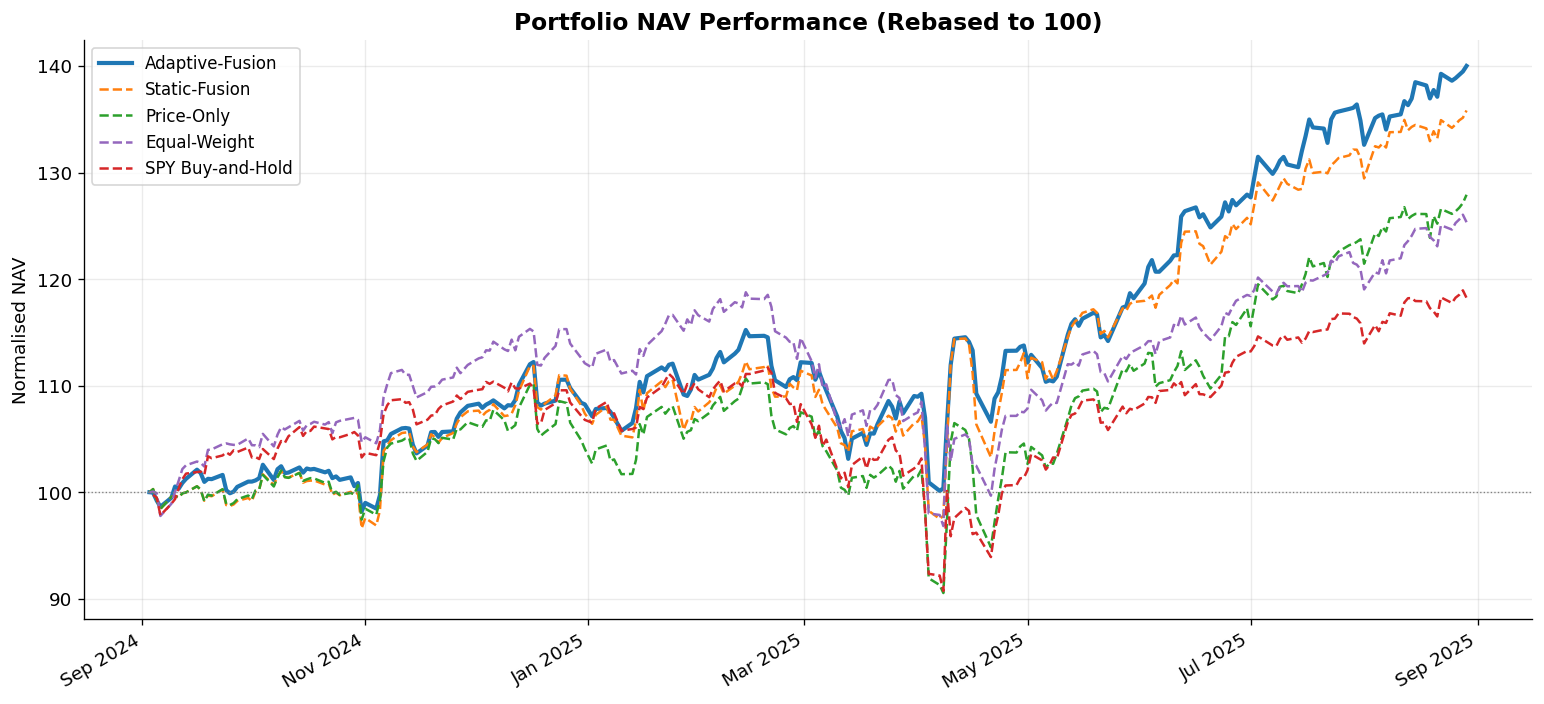

Figure 1 saved.


In [9]:
import matplotlib, matplotlib.pyplot as plt, matplotlib.dates as mdates
matplotlib.rcParams.update({"figure.dpi":120,"font.size":11,
    "axes.spines.top":False,"axes.spines.right":False})

COLORS = {"Adaptive-Fusion":"#1f77b4","Static-Fusion":"#ff7f0e",
          "Price-Only":"#2ca02c","Equal-Weight":"#9467bd","SPY Buy-and-Hold":"#d62728"}

def fmt_ax(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right"); ax.grid(True,alpha=.25)

# Figure 1: NAV
fig,ax=plt.subplots(figsize=(13,6))
for name,res in all_results.items():
    if res.nav_series.empty: continue
    nav=(res.nav_series/INITIAL_NAV)*100
    ax.plot(nav.index,nav.values,label=name,color=COLORS[name],
            lw=2.5 if name=="Adaptive-Fusion" else 1.5,
            ls="-" if name=="Adaptive-Fusion" else "--")
ax.axhline(100,color="grey",lw=0.8,ls=":")
ax.set_title("Portfolio NAV Performance (Rebased to 100)",fontsize=14,fontweight="bold")
ax.set_ylabel("Normalised NAV"); fmt_ax(ax); ax.legend(fontsize=10,loc="upper left")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"1_nav_comparison.png",dpi=300,bbox_inches="tight")
plt.show(); print("Figure 1 saved.")

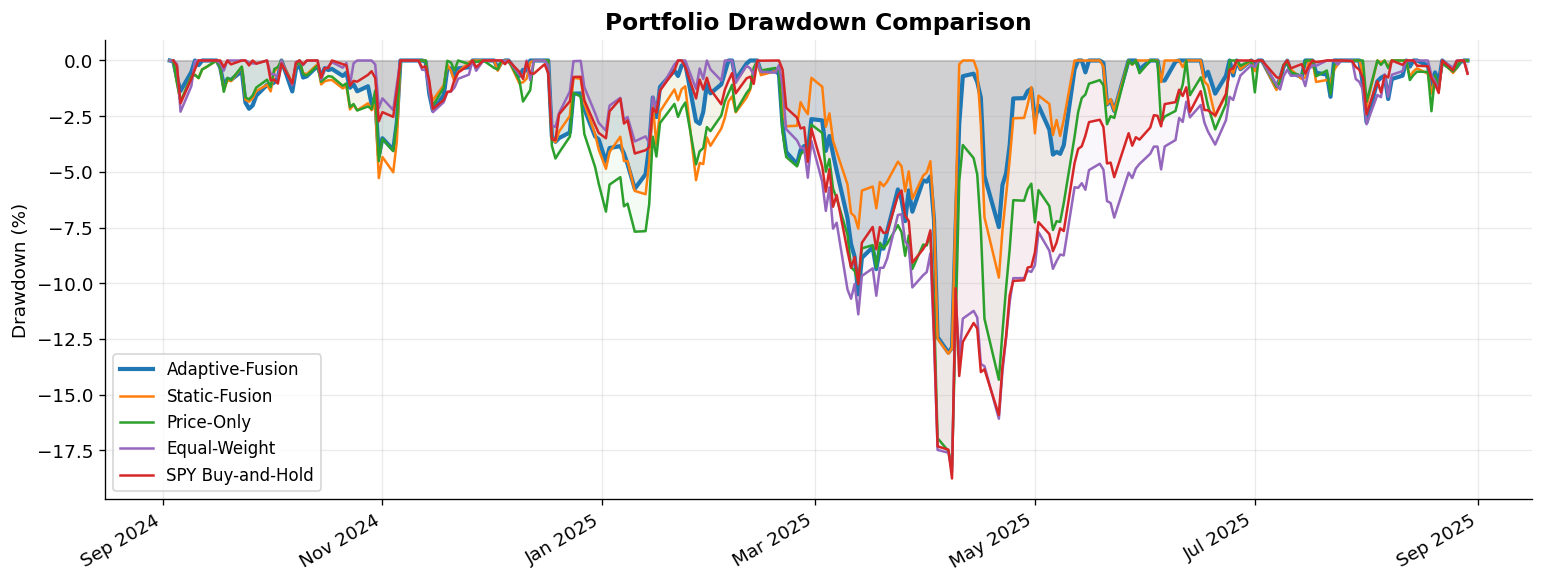

Figure 2 saved.


In [10]:
# Figure 2: Drawdown
fig,ax=plt.subplots(figsize=(13,5))
for name,res in all_results.items():
    if res.nav_series.empty: continue
    nav=res.nav_series; dd=((nav-nav.cummax())/nav.cummax())*100
    ax.plot(dd.index,dd.values,label=name,color=COLORS[name],
            lw=2.5 if name=="Adaptive-Fusion" else 1.5)
    ax.fill_between(dd.index,dd.values,0,color=COLORS[name],
                    alpha=0.15 if name=="Adaptive-Fusion" else 0.05)
ax.set_title("Portfolio Drawdown Comparison",fontsize=14,fontweight="bold")
ax.set_ylabel("Drawdown (%)"); fmt_ax(ax); ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"2_drawdown_comparison.png",dpi=300,bbox_inches="tight")
plt.show(); print("Figure 2 saved.")

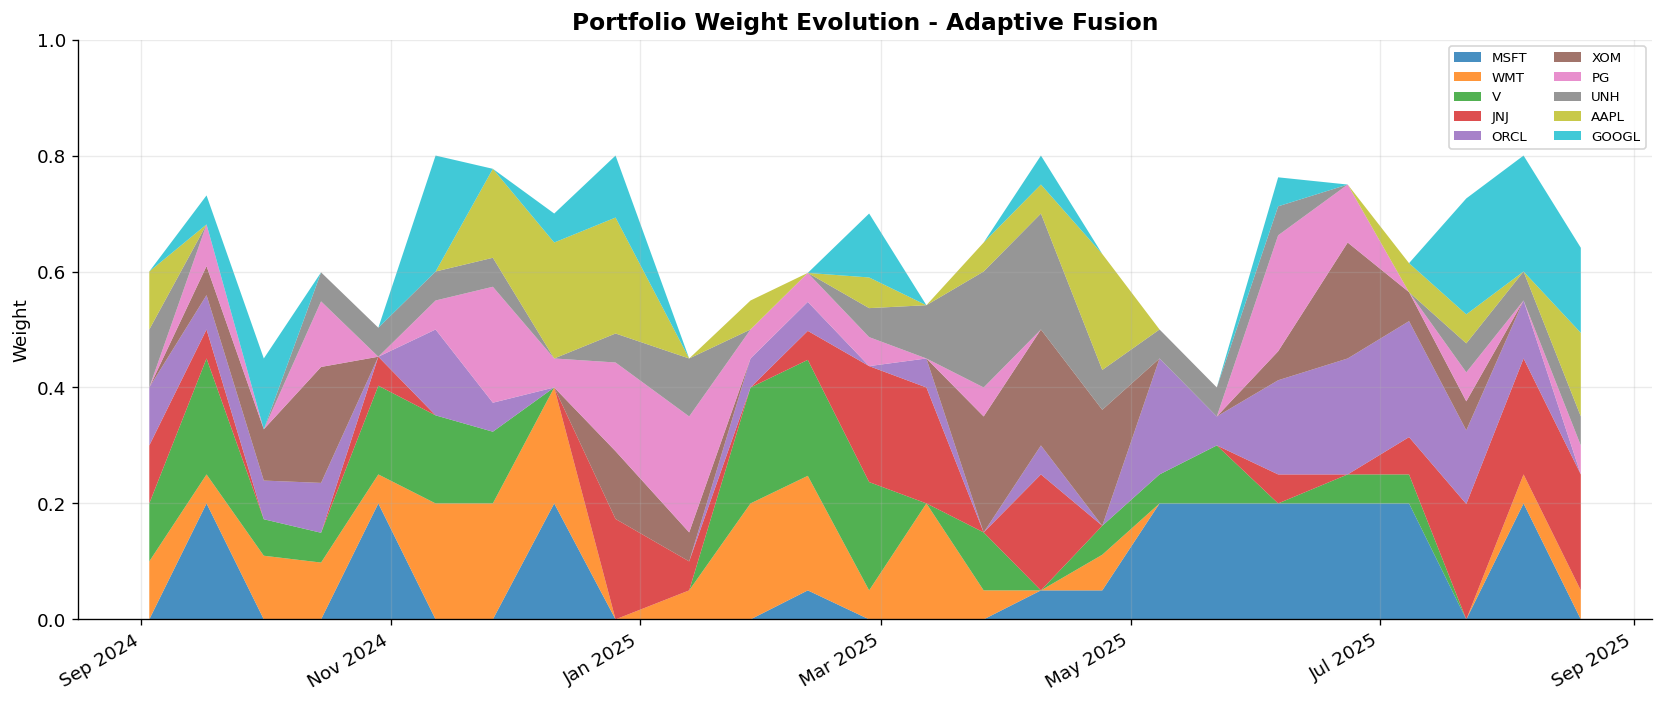

Figure 3 saved.


In [11]:
# Figure 3: Weight Evolution
if not adaptive_result.weight_history.empty:
    wh=adaptive_result.weight_history.fillna(0).clip(lower=0)
    top=wh.mean().nlargest(10).index.tolist()
    fig,ax=plt.subplots(figsize=(14,6))
    ax.stackplot(wh.index,wh[top].T.values,labels=top,alpha=0.82)
    ax.set_title("Portfolio Weight Evolution - Adaptive Fusion",fontsize=14,fontweight="bold")
    ax.set_ylabel("Weight"); ax.set_ylim(0,1); ax.legend(loc="upper right",fontsize=8,ncol=2)
    fmt_ax(ax); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"3_weight_evolution.png",dpi=300,bbox_inches="tight")
    plt.show(); print("Figure 3 saved.")

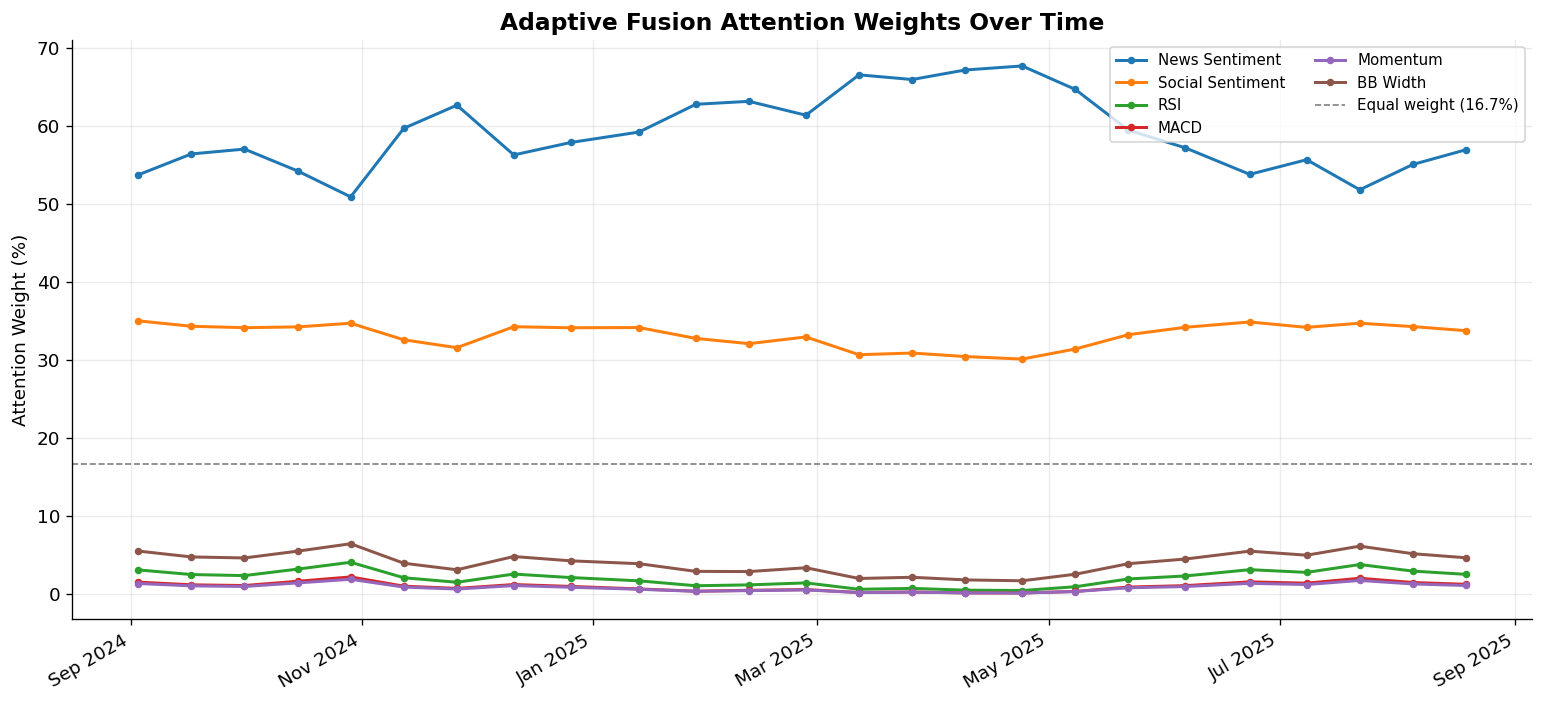

Figure 4 saved.


In [12]:
# Figure 4: Attention weights over time
rename = {"news_sentiment":"News Sentiment","social_sentiment":"Social Sentiment",
          "rsi":"RSI","macd":"MACD","momentum":"Momentum","bb_width":"BB Width"}
if adaptive_result.attention_history:
    attn=pd.DataFrame(adaptive_result.attention_history).set_index("date")
    attn.columns=[c.replace("attn_z_","").replace("attn_","") for c in attn.columns]
    attn=attn.rename(columns=rename)
    fig,ax=plt.subplots(figsize=(13,6)); cmap=plt.get_cmap("tab10")
    for i,col in enumerate(attn.columns):
        ax.plot(attn.index,attn[col]*100,label=col,lw=1.8,marker="o",ms=3.5,color=cmap(i))
    ax.axhline(100/len(attn.columns),color="grey",ls="--",lw=1,
               label=f"Equal weight ({100/len(attn.columns):.1f}%)")
    ax.set_title("Adaptive Fusion Attention Weights Over Time",fontsize=14,fontweight="bold")
    ax.set_ylabel("Attention Weight (%)"); ax.legend(fontsize=9,ncol=2)
    fmt_ax(ax); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"4_attention_weights.png",dpi=300,bbox_inches="tight")
    plt.show(); print("Figure 4 saved.")

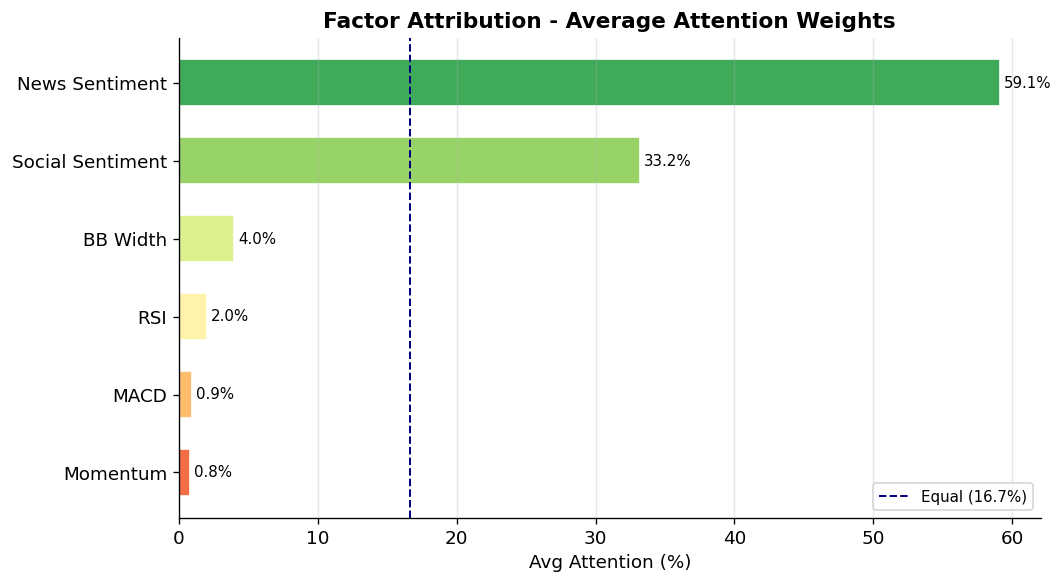

Figure 5 saved.


In [13]:
# Figure 5: Factor attribution
if adaptive_result.attention_history:
    adf=pd.DataFrame(adaptive_result.attention_history).drop(columns=["date"],errors="ignore")
    adf.columns=[c.replace("attn_z_","").replace("attn_","") for c in adf.columns]
    adf=adf.rename(columns=rename); means=adf.mean().sort_values()*100
    fig,ax=plt.subplots(figsize=(9,5))
    colors=plt.get_cmap("RdYlGn")(np.linspace(0.2,0.85,len(means)))
    bars=ax.barh(means.index,means.values,color=colors,edgecolor="white",height=0.6)
    eq=100/len(means); ax.axvline(eq,color="navy",lw=1.2,ls="--",label=f"Equal ({eq:.1f}%)")
    for bar,v in zip(bars,means.values):
        ax.text(v+0.3,bar.get_y()+bar.get_height()/2,f"{v:.1f}%",va="center",fontsize=9)
    ax.set_title("Factor Attribution - Average Attention Weights",fontsize=13,fontweight="bold")
    ax.set_xlabel("Avg Attention (%)"); ax.legend(fontsize=9); ax.grid(True,axis="x",alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"5_factor_attribution.png",dpi=300,bbox_inches="tight")
    plt.show(); print("Figure 5 saved.")

In [14]:
# Metrics summary table
rows = [{"Strategy":n,**r.metrics} for n,r in all_results.items()]
mdf  = pd.DataFrame(rows).set_index("Strategy")
ddf  = mdf.copy()
for col in ["Annualised Return","Annualised Vol","Max Drawdown","Total Return"]:
    if col in ddf: ddf[col]=ddf[col].map(lambda x:f"{x*100:+.2f}%")
for col in ["Sharpe Ratio","Calmar Ratio"]:
    if col in ddf: ddf[col]=ddf[col].map(lambda x:f"{x:.4f}")
print("\n"+"="*70)
print("STRATEGY PERFORMANCE SUMMARY")
print("="*70)
display(ddf)
print("="*70)
mdf.to_csv(OUTPUT_DIR/"metrics_summary.csv")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")


STRATEGY PERFORMANCE SUMMARY


,Sharpe Ratio,Annualised Return,Annualised Vol,Max Drawdown,Calmar Ratio,Total Return
Strategy,,,,,,
Adaptive-Fusion,2.1172,+40.76%,+19.25%,-13.11%,3.1104,+40.00%
Static-Fusion,1.7144,+36.50%,+21.29%,-13.16%,2.7734,+35.83%
Price-Only,1.2631,+28.42%,+22.50%,-18.20%,1.5617,+27.91%
Equal-Weight,1.3144,+25.68%,+19.54%,-18.47%,1.3902,+25.36%
SPY Buy-and-Hold,0.9449,+18.62%,+19.70%,-18.76%,0.9926,+18.54%



All outputs saved to: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs


In [15]:
# Adaptive Fusion trade log
trade_log_df = pd.DataFrame(adaptive_result.trade_log)
trade_log_df["date"] = pd.to_datetime(trade_log_df["date"])
trade_log_df = trade_log_df.sort_values(["date", "ticker"]).reset_index(drop=True)
trade_log_df["shares"] = trade_log_df["shares"].round(6)
trade_log_df["price"]  = trade_log_df["price"].round(4)
trade_log_df["value"]  = trade_log_df["value"].round(2)

trade_log_df.to_csv(OUTPUT_DIR / "adaptive_fusion_trade_log.csv", index=False)

print(f"Total trades : {len(trade_log_df)}")
print(f"Buys         : {(trade_log_df['action']=='BUY').sum()}")
print(f"Sells        : {(trade_log_df['action']=='SELL').sum()}")
print(f"Tickers      : {sorted(trade_log_df['ticker'].unique())}")
print(f"\nSaved → {OUTPUT_DIR / 'adaptive_fusion_trade_log.csv'}")
print()
display(trade_log_df)

Total trades : 354
Buys         : 178
Sells        : 176
Tickers      : ['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NVDA', 'ORCL', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']

Saved → C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs\adaptive_fusion_trade_log.csv



,date,ticker,action,shares,price,value
0,2024-09-03,AAPL,BUY,4.401951,227.1720,1000.00
1,2024-09-03,BRK-B,BUY,2.104211,475.2375,1000.00
2,2024-09-03,HD,BUY,2.799167,357.2491,1000.00
3,2024-09-03,JNJ,BUY,6.283956,159.1354,1000.00
4,2024-09-03,JPM,BUY,4.640330,215.5019,1000.00
...,...,...,...,...,...,...
349,2025-08-19,MSFT,SELL,5.065387,512.2816,2594.90
350,2025-08-19,ORCL,SELL,5.319227,248.2863,1320.69
351,2025-08-19,PG,BUY,4.457081,153.6351,684.76
352,2025-08-19,UNH,SELL,0.596499,305.0658,181.97
